# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 18: STRUCTURED MODEL ON 10-GENRE PILOT
# ============================================================
# Purpose:
# This notebook trains the structured modelling branch on the
# broader 10-genre pilot derived from FMA-Large.
#
# The goal is to:
# 1. Load the 10-genre pilot metadata
# 2. Align matching engineered audio features
# 3. Train structured models on the 10-genre pilot
# 4. Select the best structured model
# 5. Save outputs for later 10-genre hybrid fusion
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Seeds set to:", SEED)

Seeds set to: 42


In [2]:
# ============================================================
# 2. LOAD 10-GENRE PILOT METADATA
# ============================================================

pilot_df = pd.read_csv("../data/processed/audio_large_pilot_metadata_10genre.csv")

print("10-genre pilot metadata shape:", pilot_df.shape)
display(pilot_df.head())

print("\nClass distribution:")
print(pilot_df["genre_top"].value_counts())

print("\nSplit distribution:")
print(pilot_df["split"].value_counts())

10-genre pilot metadata shape: (6329, 5)


,track_id,genre_top,split,audio_path,audio_exists
0,183,Rock,test,../data/raw/audio/fma_large\000\000183.mp3,True
1,184,Rock,test,../data/raw/audio/fma_large\000\000184.mp3,True
2,191,Folk,training,../data/raw/audio/fma_large\000\000191.mp3,True
3,205,Folk,training,../data/raw/audio/fma_large\000\000205.mp3,True
4,306,Rock,training,../data/raw/audio/fma_large\000\000306.mp3,True



Class distribution:
genre_top
Experimental     1781
Rock             1546
Electronic        626
Pop               456
Folk              404
Hip-Hop           382
Instrumental      375
Spoken            301
International     241
Classical         217
Name: count, dtype: int64

Split distribution:
split
test          2360
validation    2169
training      1800
Name: count, dtype: int64


In [3]:
# ============================================================
# 3. LOAD FEATURES TABLE
# ============================================================

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)

features.index = features.index.astype(int)

print("Features shape:", features.shape)

Features shape: (106574, 518)


In [4]:
# ============================================================
# 4. ALIGN FEATURES TO THE 10-GENRE PILOT TRACKS
# ============================================================

pilot_df["track_id"] = pilot_df["track_id"].astype(int)

pilot_track_ids = pilot_df["track_id"].tolist()
features_pilot = features.loc[pilot_track_ids].copy()

pilot_df = pilot_df.reset_index(drop=True)
features_pilot = features_pilot.reset_index(drop=True)

print("Pilot-aligned features shape:", features_pilot.shape)
print("Recovered track IDs:", len(pilot_track_ids))
print("First few recovered track IDs:", pilot_track_ids[:5])

Pilot-aligned features shape: (6329, 518)
Recovered track IDs: 6329
First few recovered track IDs: [183, 184, 191, 205, 306]


In [5]:
# ============================================================
# 5. FLATTEN MULTIINDEX COLUMNS
# ============================================================

features_pilot.columns = [
    "_".join([str(level) for level in col]).strip()
    for col in features_pilot.columns.to_flat_index()
]

print("Flattened feature shape:", features_pilot.shape)
display(features_pilot.head())

Flattened feature shape: (6329, 518)


,chroma_cens_kurtosis_01,chroma_cens_kurtosis_02,chroma_cens_kurtosis_03,chroma_cens_kurtosis_04,chroma_cens_kurtosis_05,chroma_cens_kurtosis_06,chroma_cens_kurtosis_07,chroma_cens_kurtosis_08,chroma_cens_kurtosis_09,chroma_cens_kurtosis_10,...,tonnetz_std_04,tonnetz_std_05,tonnetz_std_06,zcr_kurtosis_01,zcr_max_01,zcr_mean_01,zcr_median_01,zcr_min_01,zcr_skew_01,zcr_std_01
0,2.060823,2.526961,0.183225,-0.483184,-0.793468,-0.778888,-0.673965,-0.723503,-0.843940,-0.291706,...,0.142481,0.020436,0.020030,4.947772,0.159668,0.041411,0.039551,0.000000,1.427251,0.018490
1,0.401024,0.278087,-0.439314,-0.697584,-0.543523,-0.430317,-0.805340,1.133633,-0.757106,-0.991473,...,0.130835,0.020204,0.019469,3.841066,0.250488,0.071994,0.068848,0.004395,1.172032,0.026247
2,-0.022110,-1.249446,-0.165796,-0.919464,-0.888402,0.937789,-0.969969,-1.109531,-0.976064,-0.571835,...,0.194829,0.027929,0.028485,75.071182,0.544922,0.049839,0.046875,0.000000,8.387897,0.050028
3,-1.294126,-0.882636,-0.670396,-1.157250,-0.933283,-0.340295,-1.156147,-1.135296,-0.845169,-1.014938,...,0.185107,0.030156,0.032795,47.463383,0.566406,0.045558,0.037598,0.000000,6.699476,0.061723
4,1.593105,2.611686,0.410375,-0.410679,0.054634,0.254629,0.824009,0.855927,-1.322009,-1.121786,...,0.062518,0.019641,0.030675,29.590654,0.329102,0.028575,0.021484,0.000000,4.548738,0.027111


In [6]:
# ============================================================
# 6. PREPARE X, y, AND split
# ============================================================

X = features_pilot.copy()
y = pilot_df["genre_top"].astype(str)
split = pilot_df["split"].astype(str)

X = X.select_dtypes(include=["number"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print("X shape:", X.shape)
print("y shape:", y.shape)
print("split shape:", split.shape)

print("\nClass distribution:")
print(y.value_counts())

print("\nSplit distribution:")
print(split.value_counts())

X shape: (6329, 518)
y shape: (6329,)
split shape: (6329,)

Class distribution:
genre_top
Experimental     1781
Rock             1546
Electronic        626
Pop               456
Folk              404
Hip-Hop           382
Instrumental      375
Spoken            301
International     241
Classical         217
Name: count, dtype: int64

Split distribution:
split
test          2360
validation    2169
training      1800
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
print(label_encoder.classes_)

Encoded classes:
['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock' 'Spoken']


In [8]:
# ============================================================
# 8. CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

train_mask = (split == "training").values
val_mask = (split == "validation").values
test_mask = (split == "test").values

X_train = X.loc[train_mask].copy()
y_train = y_encoded[train_mask]

X_val = X.loc[val_mask].copy()
y_val = y_encoded[val_mask]

X_test = X.loc[test_mask].copy()
y_test = y_encoded[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1800, 518) (1800,)
Validation: (2169, 518) (2169,)
Test: (2360, 518) (2360,)


In [9]:
# ============================================================
# 9. SCALE FEATURES FOR LR AND SVM
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [10]:
# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================

print("\n===== LOGISTIC REGRESSION =====")

lr_model = LogisticRegression(
    max_iter=3000,
    random_state=SEED
)

lr_model.fit(X_train_scaled, y_train)

val_pred_lr = lr_model.predict(X_val_scaled)
val_probs_lr = lr_model.predict_proba(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_lr))

print(classification_report(
    y_val,
    val_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== LOGISTIC REGRESSION =====
Validation Accuracy: 0.36053480866758875
               precision    recall  f1-score   support

    Classical       0.03      0.17      0.06        12
   Electronic       0.30      0.34      0.32       239
 Experimental       0.61      0.29      0.39       741
         Folk       0.20      0.49      0.28        77
      Hip-Hop       0.33      0.41      0.37        99
 Instrumental       0.06      0.27      0.10        60
International       0.22      0.69      0.33        35
          Pop       0.15      0.18      0.16       191
         Rock       0.66      0.46      0.54       613
       Spoken       0.36      0.49      0.42       102

     accuracy                           0.36      2169
    macro avg       0.29      0.38      0.30      2169
 weighted avg       0.48      0.36      0.39      2169



In [11]:
# ============================================================
# 11. RANDOM FOREST
# ============================================================

print("\n===== RANDOM FOREST =====")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

val_pred_rf = rf_model.predict(X_val)
val_probs_rf = rf_model.predict_proba(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_rf))

print(classification_report(
    y_val,
    val_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== RANDOM FOREST =====
Validation Accuracy: 0.43337943752881514
               precision    recall  f1-score   support

    Classical       0.09      0.58      0.16        12
   Electronic       0.36      0.36      0.36       239
 Experimental       0.72      0.24      0.36       741
         Folk       0.26      0.70      0.38        77
      Hip-Hop       0.29      0.64      0.40        99
 Instrumental       0.08      0.20      0.11        60
International       0.26      0.89      0.40        35
          Pop       0.24      0.17      0.20       191
         Rock       0.68      0.70      0.69       613
       Spoken       0.31      0.47      0.38       102

     accuracy                           0.43      2169
    macro avg       0.33      0.49      0.34      2169
 weighted avg       0.54      0.43      0.44      2169



In [12]:
# ============================================================
# 12. SVM
# ============================================================

print("\n===== SVM =====")

svm_model = SVC(
    C=10,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=SEED
)

svm_model.fit(X_train_scaled, y_train)

val_pred_svm = svm_model.predict(X_val_scaled)
val_probs_svm = svm_model.predict_proba(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_svm))

print(classification_report(
    y_val,
    val_pred_svm,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== SVM =====
Validation Accuracy: 0.44029506685108344
               precision    recall  f1-score   support

    Classical       0.12      0.42      0.19        12
   Electronic       0.33      0.46      0.38       239
 Experimental       0.69      0.34      0.45       741
         Folk       0.24      0.62      0.35        77
      Hip-Hop       0.35      0.41      0.38        99
 Instrumental       0.08      0.33      0.13        60
International       0.33      0.77      0.46        35
          Pop       0.20      0.21      0.21       191
         Rock       0.75      0.60      0.67       613
       Spoken       0.46      0.48      0.47       102

     accuracy                           0.44      2169
    macro avg       0.36      0.46      0.37      2169
 weighted avg       0.56      0.44      0.47      2169



In [13]:
# ============================================================
# 13. MODEL COMPARISON SUMMARY
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, val_pred_lr),
        accuracy_score(y_val, val_pred_rf),
        accuracy_score(y_val, val_pred_svm)
    ]
})

print("10-Genre Structured Model Comparison:")
display(model_results)

10-Genre Structured Model Comparison:


,Model,Validation Accuracy
0,Logistic Regression,0.360535
1,Random Forest,0.433379
2,SVM,0.440295


In [14]:
# ============================================================
# 14. SELECT BEST STRUCTURED MODEL
# ============================================================

validation_scores = {
    "Logistic Regression": accuracy_score(y_val, val_pred_lr),
    "Random Forest": accuracy_score(y_val, val_pred_rf),
    "SVM": accuracy_score(y_val, val_pred_svm)
}

best_model_name = max(validation_scores, key=validation_scores.get)
print("Best 10-genre structured model:", best_model_name)

Best 10-genre structured model: SVM


In [15]:
# ============================================================
# 15. FINAL TEST EVALUATION FOR BEST MODEL
# ============================================================

if best_model_name == "Logistic Regression":
    best_model = lr_model
    test_pred_best = best_model.predict(X_test_scaled)
    test_probs_best = best_model.predict_proba(X_test_scaled)

elif best_model_name == "Random Forest":
    best_model = rf_model
    test_pred_best = best_model.predict(X_test)
    test_probs_best = best_model.predict_proba(X_test)

else:
    best_model = svm_model
    test_pred_best = best_model.predict(X_test_scaled)
    test_probs_best = best_model.predict_proba(X_test_scaled)

structured_test_accuracy = accuracy_score(y_test, test_pred_best)

print("10-Genre Best Structured Model Test Accuracy:", structured_test_accuracy)

print(classification_report(
    y_test,
    test_pred_best,
    target_names=label_encoder.classes_,
    zero_division=0
))

10-Genre Best Structured Model Test Accuracy: 0.43177966101694915
               precision    recall  f1-score   support

    Classical       0.35      0.68      0.46        25
   Electronic       0.28      0.51      0.36       207
 Experimental       0.74      0.33      0.46       860
         Folk       0.25      0.39      0.30       147
      Hip-Hop       0.56      0.77      0.65       103
 Instrumental       0.08      0.16      0.11       135
International       0.13      0.35      0.19        26
          Pop       0.03      0.09      0.05        85
         Rock       0.81      0.56      0.66       753
       Spoken       0.21      0.95      0.34        19

     accuracy                           0.43      2360
    macro avg       0.34      0.48      0.36      2360
 weighted avg       0.60      0.43      0.47      2360



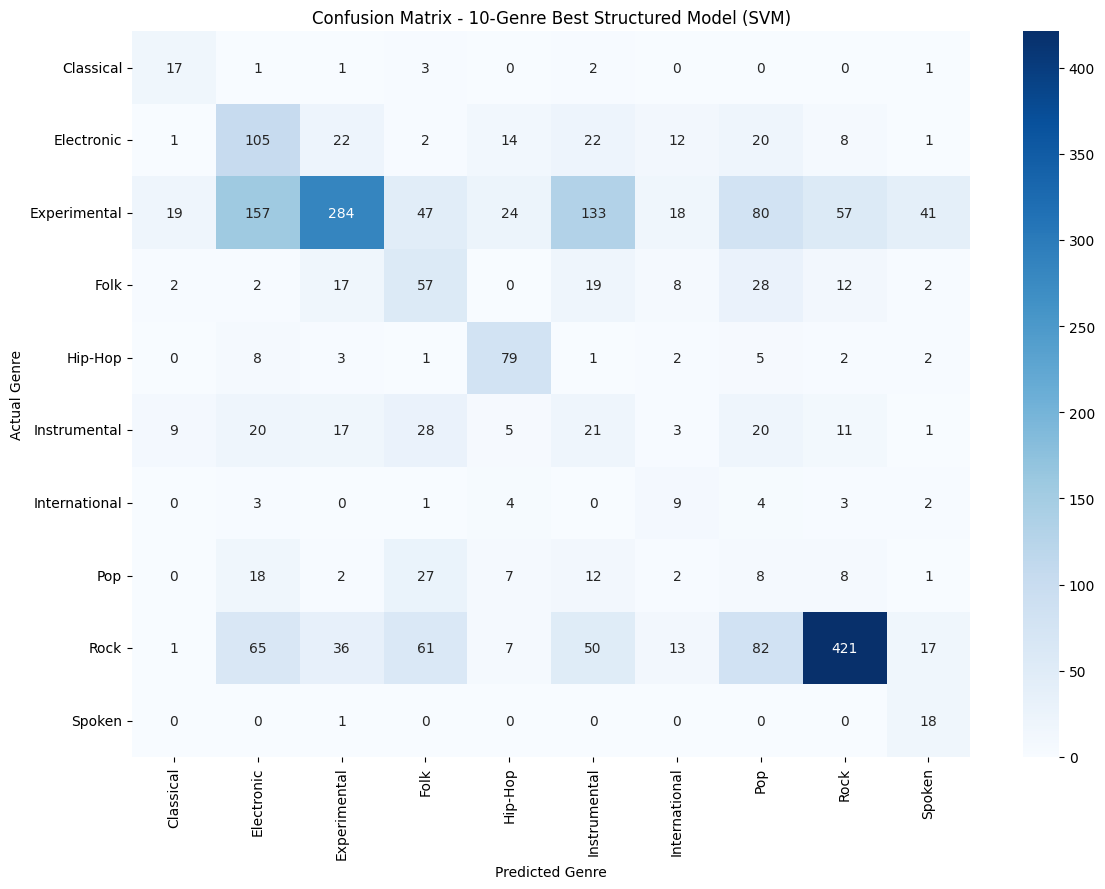

In [16]:
# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, test_pred_best)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title(f"Confusion Matrix - 10-Genre Best Structured Model ({best_model_name})")
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 17. FEATURE IMPORTANCE (IF RF IS BEST)
# ============================================================

if best_model_name == "Random Forest":
    feature_importance = pd.Series(
        rf_model.feature_importances_,
        index=X.columns
    )

    top_features = feature_importance.sort_values(ascending=False).head(20)

    print("Top 20 Important Features:")
    print(top_features)

    plt.figure(figsize=(12, 8))
    top_features.sort_values().plot(kind="barh")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.title("Top 20 Important Features - 10-Genre Random Forest")
    plt.tight_layout()
    plt.show()

In [18]:
# ============================================================
# 18. SAVE MODEL AND OUTPUTS
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

joblib.dump(best_model, "../models/best_structured_model_10genre.joblib")

np.save("../data/processed/structured_feature_columns_10genre.npy", X.columns.to_numpy())

np.save("../data/processed/val_probs_lr_10genre.npy", val_probs_lr)
np.save("../data/processed/val_probs_rf_10genre.npy", val_probs_rf)
np.save("../data/processed/val_probs_svm_10genre.npy", val_probs_svm)

np.save("../data/processed/structured_test_probs_best_10genre.npy", test_probs_best)

np.save("../data/processed/y_val_structured_10genre.npy", y_val)
np.save("../data/processed/y_test_structured_10genre.npy", y_test)

np.save("../data/processed/structured_label_classes_10genre.npy", label_encoder.classes_)

with open("../data/processed/best_structured_model_name_10genre.txt", "w") as f:
    f.write(best_model_name)

with open("../data/processed/best_structured_model_test_accuracy_10genre.txt", "w") as f:
    f.write(str(structured_test_accuracy))

print("Saved 10-genre structured model and outputs.")

Saved 10-genre structured model and outputs.


In [19]:
# ============================================================
# 19. INTERPRETATION NOTES
# ============================================================

print("1. This notebook trains the structured branch on the broader 10-genre pilot.")
print("2. The 10-genre task is harder than the earlier 8-genre pilot because the label space is broader.")
print("3. The saved outputs will be used for later 10-genre hybrid fusion.")
print("4. The next step is to combine the 10-genre structured and audio branches.")

1. This notebook trains the structured branch on the broader 10-genre pilot.
2. The 10-genre task is harder than the earlier 8-genre pilot because the label space is broader.
3. The saved outputs will be used for later 10-genre hybrid fusion.
4. The next step is to combine the 10-genre structured and audio branches.


In [ ]:
# ============================================================
# 20. SAVE SCALER FOR 10-GENRE INFERENCE
# ============================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(scaler, "../models/structured_scaler_10genre.joblib")

print("Saved 10-genre structured scaler.")

Saved 10-genre structured scaler.
